In [2]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [6]:
def Process_WaterPhantomData(filepath, norm):
    #####
    # Process csv data for water phantom, obtained from LET export script, into a line dose

    # INPUTS 
    # filepath = path to csv file
    # norm = 0 or 1, depending on if you want the dose normalised to max
    # 
    # OUTPUTS 
    # dosedata = dose data along central line of phantom
    # letdata = LET data along central line of phantom

    data_waterphantom = pd.read_csv(filepath)

    #Find middle x and y
    x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
    z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

    #Extract data with this x and y
    lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]

    #Process data
    ydata = np.array(abs(lineprofile['y_mm']))
    let = np.array(lineprofile['LET_keV_per_um'])
    dose = np.array(lineprofile['Physical_dose'])

    #Want depth to start at zero
    ydata = ydata - min(ydata)
    #Sort depth data in ascending order
    sort = np.argsort(ydata)
    #Apply sorting to all variables
    ydata = ydata[sort]
    let = let[sort]
    dose = dose[sort]

    #normalise dose data
    if norm == 1:
        dose = dose/max(dose)

    #Truncate data once dose drops to zero
    stopindex = np.where(dose<0.01)[0][0]
    ydata = ydata[0:stopindex]
    let = let[0:stopindex]
    dose = dose[0:stopindex]

    #Write to pandas
    let = pd.DataFrame({'y_mm': ydata, 'LET': let})
    dose = pd.DataFrame({'y_mm': ydata, 'Dose': dose})

    return dose, let

In [7]:
#Data without range shifter
dose_no_range, let_no_range = Process_WaterPhantomData(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Water phantom data new energy\Pristine 69.87 MeV in Water Phantom.csv",0)

#Data with range shifter
dose_range, let_range = Process_WaterPhantomData(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Water phantom data new energy\Range Shifter 69.87 MeV in Water Phantom.csv",0)


In [23]:
#Interpolate
dose_nr = pd.DataFrame(columns=['Depth', 'Dose'])
dose_nr['Depth'] = np.arange(dose_no_range['y_mm'].iloc[0], dose_no_range['y_mm'].iloc[len(dose_no_range)-1], 0.01)
dose_nr['Dose'] = np.interp(dose_nr['Depth'], dose_no_range['y_mm'], dose_no_range['Dose'])

dose_r = pd.DataFrame(columns=['Depth', 'Dose'])
dose_r['Depth'] = np.arange(dose_range['y_mm'].iloc[0], dose_range['y_mm'].iloc[len(dose_range)-1], 0.01)
dose_r['Dose'] = np.interp(dose_r['Depth'], dose_range['y_mm'], dose_range['Dose'])

Text(0, 0.5, 'Dose (Gy)')

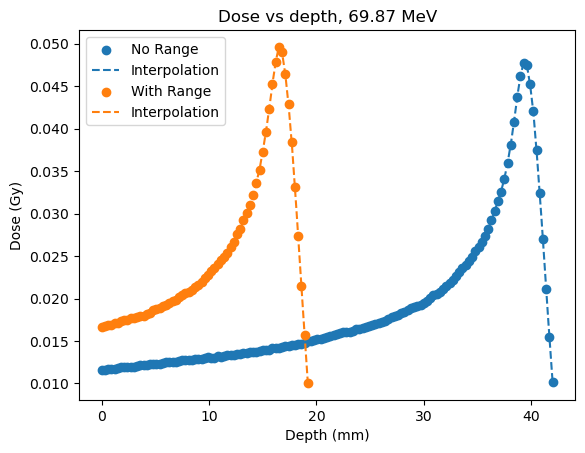

In [38]:
#plot
plt.scatter(dose_no_range['y_mm'], dose_no_range['Dose'], label = 'No Range')
plt.plot(dose_nr['Depth'], dose_nr['Dose'], ls='--', label='Interpolation')
plt.scatter(dose_range['y_mm'], dose_range['Dose'], label = 'With Range')
plt.plot(dose_r['Depth'], dose_r['Dose'], ls = '--', label='Interpolation')
plt.legend()
plt.title('Dose vs depth, 69.87 MeV')
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy)')

Calculate shift in dose peak

In [37]:
peak_location_nr = dose_nr['Depth'].iloc[np.argmax(dose_nr['Dose'])]

peak_location_r = dose_r['Depth'].iloc[np.argmax(dose_r['Dose'])]

shift = peak_location_nr - peak_location_r

print('Shift in peak: ' + str(round(shift, 2)) + ' mm')

Shift in peak: 22.8 mm


In [45]:
R_nr = 0.8*np.argmax(dose_nr['Dose'])

R_r = 0.8*np.argmax(dose_r['Dose'])

location_nr = dose_nr['Depth'].iloc[np.argmin(dose_nr['Dose']-R_nr)]

location_r = dose_r['Depth'].iloc[np.argmin(dose_r['Dose']-R_r)]

shift = location_nr - location_r

print('Shift in peak: ' + str(round(shift, 2)) + ' mm')

Shift in peak: 22.79 mm
